In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/train.csv


In [2]:
pip install Keras

Note: you may need to restart the kernel to use updated packages.


In [3]:
import keras
from keras.models import Sequential
from keras.layers import Dense

Using TensorFlow backend.


In [4]:
path_train = '/kaggle/input/digit-recognizer/train.csv'

In [5]:
path_test = '/kaggle/input/digit-recognizer/test.csv'

In [6]:
train_data = pd.read_csv(path_train)


In [7]:
train_data.shape

(42000, 785)

In [8]:
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
test_data = pd.read_csv(path_test)

In [10]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
test_data.shape

(28000, 784)

In [12]:
## split the train data into labels ([:0]) and image ([1:])

X_images = train_data.iloc[:, 1:]
Y_labels = train_data.iloc[:, :1]

In [13]:
X_images.shape

(42000, 784)

In [14]:
X_images.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
Y_labels.shape

(42000, 1)

In [16]:
Y_labels.head()

,label
0,1
1,0
2,1
3,4
4,0


In [17]:
## pre processing the images data into numpy array:
X_images_train = X_images.to_numpy().reshape(42000, 28 * 28).astype('float32')/ 255

test_data = test_data.to_numpy().reshape(28000, 28 * 28).astype('float32')/255

In [18]:
#pre processing the lable data 
from keras.utils import to_categorical
Y_labels_train = to_categorical(Y_labels.to_numpy(), 10)

In [19]:
## building my very first Neural Network
network = Sequential()
network.add(Dense(512, activation = 'relu', input_shape = (28 * 28, )))
network.add(Dense (10, activation = 'softmax'))

In [20]:
## network compilation
network.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [21]:
## fitting the model to the training data 
Model = network.fit(X_images_train, Y_labels_train, epochs = 5, batch_size=128, validation_split = 0.2)

Train on 33600 samples, validate on 8400 samples
Epoch 1/5
33600/33600 [==============================] - 3s 95us/step - loss: 0.3236 - accuracy: 0.9060 - val_loss: 0.1826 - val_accuracy: 0.9463
Epoch 2/5
33600/33600 [==============================] - 3s 89us/step - loss: 0.1389 - accuracy: 0.9598 - val_loss: 0.1245 - val_accuracy: 0.9633
Epoch 3/5
33600/33600 [==============================] - 3s 89us/step - loss: 0.0905 - accuracy: 0.9737 - val_loss: 0.1027 - val_accuracy: 0.9680
Epoch 4/5
33600/33600 [==============================] - 3s 89us/step - loss: 0.0640 - accuracy: 0.9811 - val_loss: 0.0863 - val_accuracy: 0.9736
Epoch 5/5
33600/33600 [==============================] - 3s 90us/step - loss: 0.0476 - accuracy: 0.9866 - val_loss: 0.0800 - val_accuracy: 0.9755


In [22]:
import matplotlib.pyplot as plt

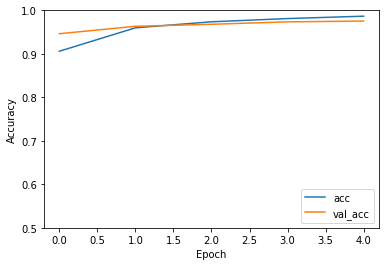

In [23]:
## model evaluation

plt.plot(Model.history['accuracy'], label='acc')
plt.plot(Model.history['val_accuracy'], label = 'val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [24]:
## submission, predicting the labels of the test images provided
Prediction_labels = network.predict(test_data)

In [25]:
np.savetxt('submission.csv', np.c_[range(1,len(Prediction_labels)+1),Prediction_labels], delimiter=',', 
           header = 'ImageId,Label', comments = '', fmt='%d')